In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,5) * nm #voy a cambiar el numero de puntos a 5 
#Wavelength 1.5-1.6 µm (step 0.02 µm) – width 1.2 µm
f = td.C_0 / wavelength

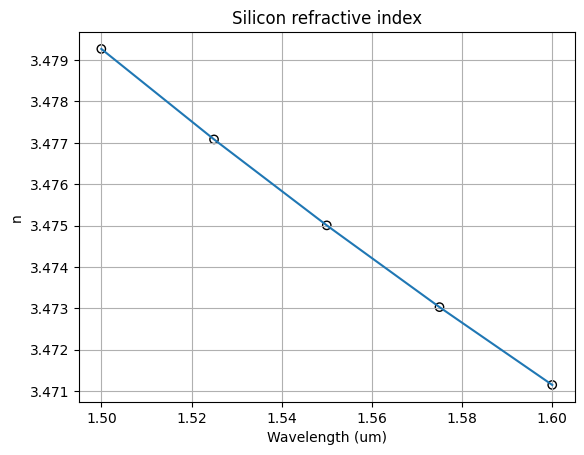

In [2]:
##TENEMOS EL SILICIO
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

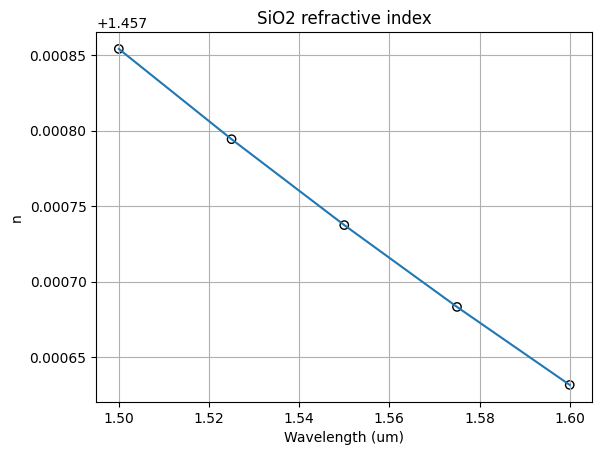

In [3]:
#tenemos el sio2
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

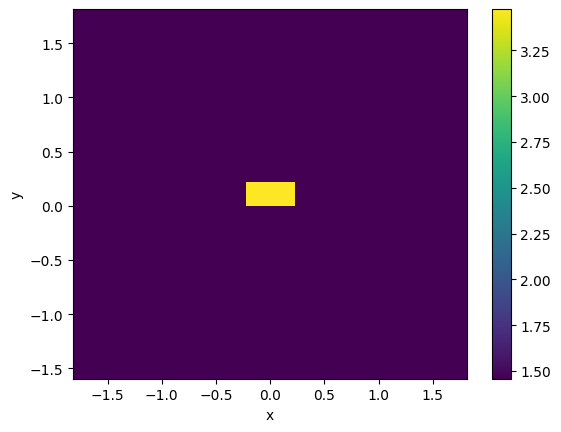

In [4]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    #si le ponemos un escalon de 200 nm en vez de 0
    # Materials
    core_material='si', #  Material of the waveguide --si cambiamos silicon nitride "sin" 
    #por silicio "si" veremos el cambio de indice en la cubierta
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=6, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    #Si cambiamos la resolución pueden cambiar los calculos numéricos posteriores
    #Tener cuidado, habrá que coger valores correctos que veremos en proximas sesiones
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

In [5]:
deep_waveguide.n_eff

2026-03-23 15:37:28.032 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f3565ec70eb8b5e7.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207047e-04j,
       1.42725536+2.19956436e-04j, 1.42652548+2.21255961e-04j])

In [6]:
#para índices efectivos por debajo de aproximadamente 1.475
#ya no se propagarán los modos
#por lo que para 1550 se propagrán los 2 primeros modos 

In [7]:
deep_waveguide.fraction_te 

array([0.960726  , 0.06940437, 0.64309704, 0.99810643, 0.34574821,
       0.01031772])

In [8]:
#el primer modo es quasi TE

In [9]:
deep_waveguide.fraction_tm 

array([0.039274  , 0.93059563, 0.35690296, 0.00189357, 0.65425179,
       0.98968228])

In [10]:
#El segundo modo es quasi TM

In [11]:
#Si trabajamos la polarización es monomodo


Text(0.5, 1.0, 'Modo fundamental TE')

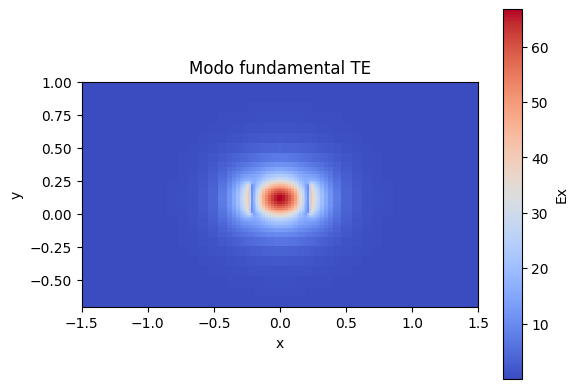

In [12]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          #vamos a buscar el modo en x porque habiamos visto que era muy te
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo fundamental TE') # You might need this later :) 

Text(0.5, 1.0, 'Modo fundamental TM')

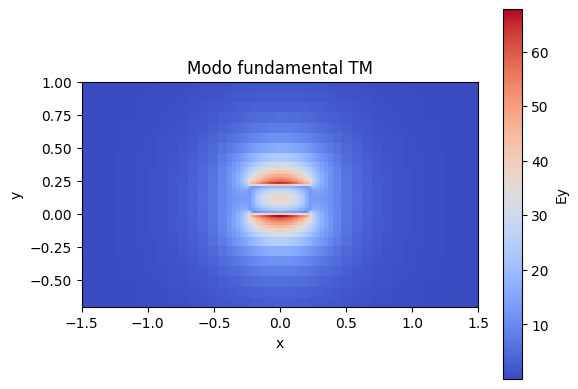

In [13]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          #vamos a buscar el modo en x porque habiamos visto que era muy te
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo fundamental TM') # You might need this later :) 

2026-03-23 15:37:28.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2683154ecea875ca.npz.


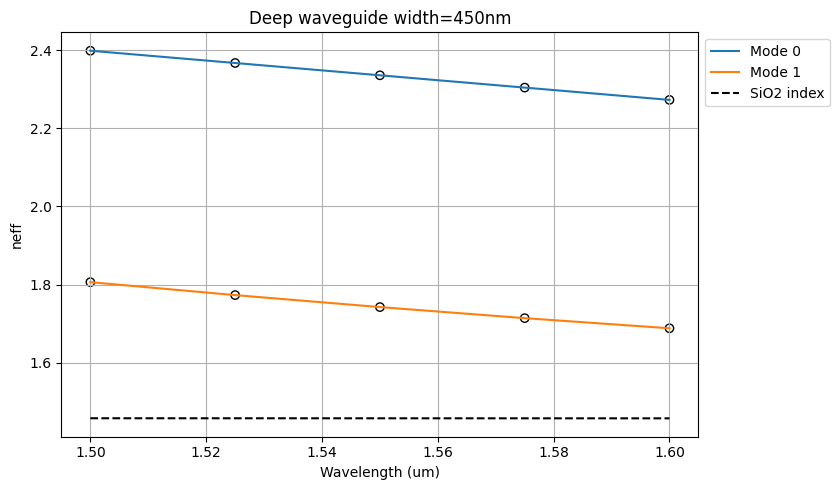

In [14]:
# The wavelength could be a vector also
wavelength = np.linspace(1500, 1600,5) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450* nm, 
    slab_thickness=0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={450}nm")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [15]:
#ajustamos el grid


2026-03-23 15:37:28.783 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2ca679d264883e6e.npz.
  neff mode 0 = [np.complex128(2.455547531462677+5.414953067132406e-05j)]
2026-03-23 15:37:28.792 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_56d529e0207ae53a.npz.
  neff mode 0 = [np.complex128(2.455547531462677+5.414953067132406e-05j), np.complex128(2.335750322719535+7.04687632849446e-05j)]
2026-03-23 15:37:28.798 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_363edc77f37e8efe.npz.
  neff mode 0 = [np.complex128(2.455547531462677+5.414953067132406e-05j), np.complex128(2.335750322719535+7.04687632849446e-05j), np.complex128(2.356363689262615+6.515815920092671e-05j)]
2026-03-23 15:37:28.805 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1631ae352e063ef7.npz.
  neff mode 0 = [np.complex128(2.455547531462677+5.414953067132406e-05j), np.complex128(2.335750322719535+7.0

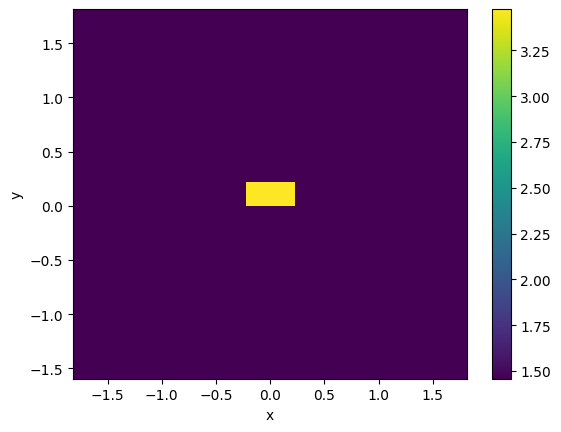

In [16]:
#Variamos el grid_resolution
n_eff = []

grid_values = range (10, 101, 10)


for grid in grid_values:

 deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find 
    max_grid_scaling=1.3, # Parameters of the grid 
    grid_resolution=grid, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    #siempre tener el cache activo, 
    precision='double',
 )
 n_eff.append(deep_waveguide.n_eff[0])


 print(f"  neff mode 0 = {n_eff}")
print("Sweep finished.")
deep_waveguide.plot_index()

/home/rober/FINAL_PROJECT_ENVIRONMENT/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rober/FINAL_PROJECT_ENVIRONMENT/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


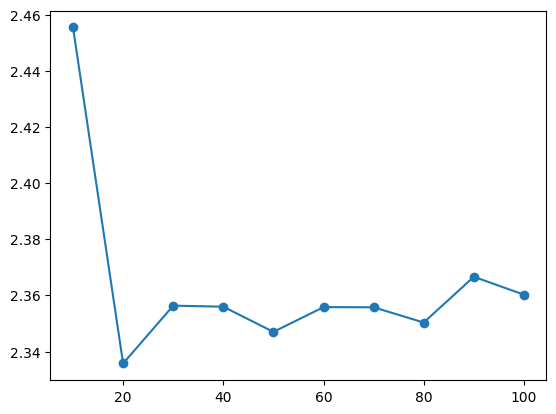

In [17]:
plt.plot(list(grid_values), n_eff, marker='o') #ploteamos los valores respecto al incremento de grid

In [18]:
#cogeré un valor de 30 para el grid resolution

2026-03-23 15:37:29.239 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1cf7ab619c6fa524.npz.
  neff mode 0 = [np.complex128(2.3884501664194806+6.154004275814023e-05j)]
2026-03-23 15:37:29.245 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_363edc77f37e8efe.npz.
  neff mode 0 = [np.complex128(2.3884501664194806+6.154004275814023e-05j), np.complex128(2.356363689262615+6.515815920092671e-05j)]
2026-03-23 15:37:29.248 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2bf372cae8a41e5.npz.
  neff mode 0 = [np.complex128(2.3884501664194806+6.154004275814023e-05j), np.complex128(2.356363689262615+6.515815920092671e-05j), np.complex128(2.35617681146751+6.51855724799066e-05j)]
2026-03-23 15:37:29.253 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_115dff69260a160e.npz.
  neff mode 0 = [np.complex128(2.3884501664194806+6.154004275814023e-05j), np.complex128(2.356363689262615

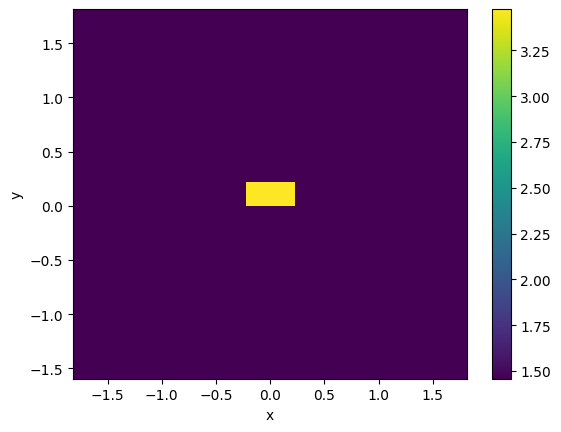

In [19]:
#variamos el max_grid
n_eff = []

grid_values = np.linspace(1.2, 1.6, 5)


for grid in grid_values:

 deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 *nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find 
    max_grid_scaling=grid, # Parameters of the grid 
    grid_resolution=30, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    #siempre tener el cache activo, 
    precision='double',
 )
 n_eff.append(deep_waveguide.n_eff[0])


 print(f"  neff mode 0 = {n_eff}")
print("Sweep finished.")
deep_waveguide.plot_index()


/home/rober/FINAL_PROJECT_ENVIRONMENT/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rober/FINAL_PROJECT_ENVIRONMENT/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


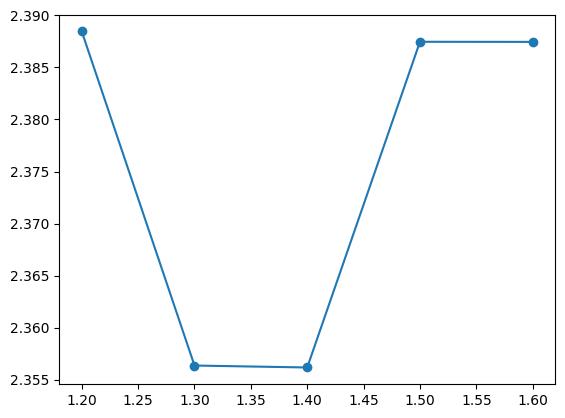

In [20]:
plt.plot(list(grid_values), n_eff, marker='o') #ploteamos los valores respecto al incremento de grid

In [21]:
 #1.3 cogeré

Transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the **compact models** of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.


2026-03-23 15:37:29.573 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_11ca236af7774a21.npz.


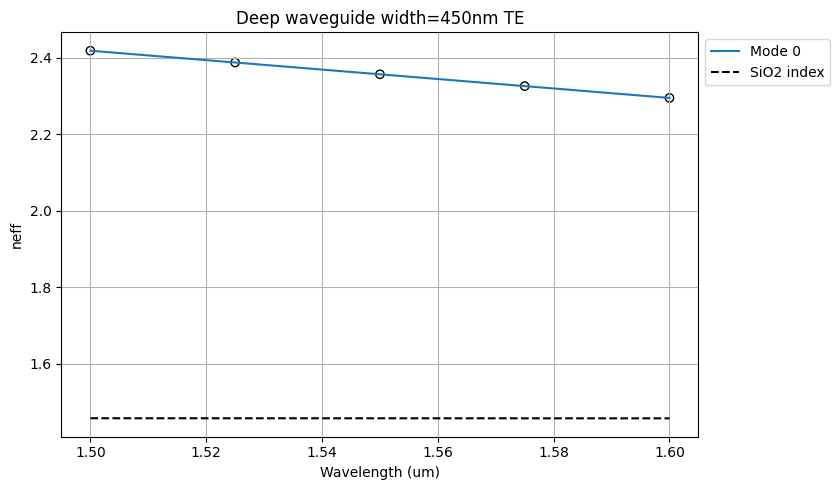

In [22]:
#DEEP wave_guide TE
wavelength = np.linspace(1500, 1600,5) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450*nm, 
    slab_thickness=0*nm, #no tenemos slab en la deep
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2, #vampos a ver 
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3, #ponemos estos valores de acuerdo a lo de antes
    grid_resolution=30, 
)

res_neff = deep_waveguide.n_eff# queremos el primer modo TE# In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
#for k in range(res_neff.shape[1]):
     #It's necessary to 'access' each element on the array
    #plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    #plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
# quitamos el for
plt.scatter(wavelength, res_neff[:,0].real, edgecolors='k', facecolors='none')

plt.plot(wavelength, res_neff[:,0].real, label='Mode 0')
plt.title(f"Deep waveguide width={450}nm TE")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

Waveguide(wavelength=array([1.5  , 1.525, 1.55 , 1.575, 1.6  ]), core_width='0.45', core_thickness='0.22', core_material='si', clad_material='sio2', box_material=None, slab_thickness='0.0', clad_thickness=None, box_thickness=None, side_margin=None, sidewall_angle='0.0', sidewall_thickness='0.0', sidewall_k='0.0', surface_thickness='0.0', surface_k='0.0', bend_radius=None, num_modes='1', group_index_step='False', precision='double', grid_resolution='30', max_grid_scaling='1.3', cache_path='.cache/', overwrite='False')
2026-03-23 15:37:29.747 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_39667cdd340ba68c.npz.
[2.41814854 2.38735769 2.35652324 2.32566097 2.29479011]
[1.5   1.525 1.55  1.575 1.6  ]
[-0.05  -0.025  0.     0.025  0.05 ]
a, b, c = -0.021465874485931066 -1.2336543226514405 2.3565229423184872


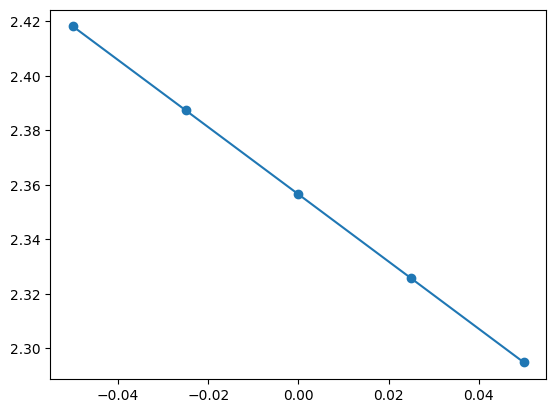

In [23]:
#DEEP wave_guide TE
wavelength = np.linspace(1500, 1600,5) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450*nm, 
    slab_thickness=0*nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1, #solo hago el modo fundamental TE 
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=30, 
)
print(deep_waveguide)
res_neff = deep_waveguide.n_eff #TENGO PARA CADA LONGITUD DE ONDA SU VALOR # queremos el primer modo TE# In this case, the result is not just a number, is a wavelength-dependent vector
neff_ef_lambda_fundamental_te = res_neff.real
print(neff_ef_lambda_fundamental_te)
print(wavelength)

#ahora tenemos wavelegth y neff_ef_lambda_fundamental_te
#utilizamos polifit para sacar el polinomio de 2do orden
       # o tu variable lambda_values
y = neff_ef_lambda_fundamental_te   
#como dice el enunciado debo hacer el desplazamiento 
lam_array = wavelength-1.55
print(lam_array)
coeffs = np.polyfit(lam_array,y , 2)  # [a, b, c]
a, b, c = coeffs
print("a, b, c =", a, b, c)
y_fit = np.polyval(coeffs, lam_array)   
plt.scatter(lam_array, y)
plt.plot(lam_array, y_fit)
plt.show()

In [24]:
n2 = b
n1 = c
n_g = n1 - n2 * 1550*nm
print("n_g(lambda0) =", n_g)

n_g(lambda0) = 4.26868714242822


2026-03-23 15:37:29.859 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_11ca236af7774a21.npz.


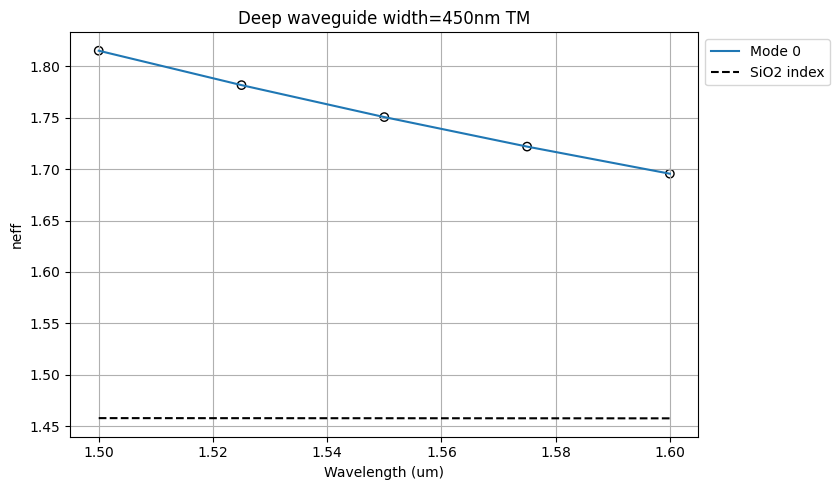

In [25]:
#DEEP wave_guide TM
wavelength = np.linspace(1500, 1600,5) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450*nm, 
    slab_thickness=0*nm, #no tenemos slab en la deep
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2, #vampos a ver 
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3, #ponemos estos valores de acuerdo a lo de antes
    grid_resolution=30, 
)

res_neff = deep_waveguide.n_eff# queremos el primer modo TE# In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
#for k in range(res_neff.shape[1]):
     #It's necessary to 'access' each element on the array
    #plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    #plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
# quitamos el for
plt.scatter(wavelength, res_neff[:,1].real, edgecolors='k', facecolors='none')

plt.plot(wavelength, res_neff[:,1].real, label='Mode 0')
plt.title(f"Deep waveguide width={450}nm TM")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

Waveguide(wavelength=array([1.5  , 1.525, 1.55 , 1.575, 1.6  ]), core_width='0.45', core_thickness='0.22', core_material='si', clad_material='sio2', box_material=None, slab_thickness='0.0', clad_thickness=None, box_thickness=None, side_margin=None, sidewall_angle='0.0', sidewall_thickness='0.0', sidewall_k='0.0', surface_thickness='0.0', surface_k='0.0', bend_radius=None, num_modes='2', group_index_step='False', precision='double', grid_resolution='30', max_grid_scaling='1.3', cache_path='.cache/', overwrite='False')
2026-03-23 15:37:30.062 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_11ca236af7774a21.npz.
[1.81518667 1.78172101 1.75063719 1.7219304  1.69555618]
[1.5   1.525 1.55  1.575 1.6  ]
[-0.05  -0.025  0.     0.025  0.05 ]
a, b, c = 1.8925620242564807 -1.1962063829923888 1.7506405880135039


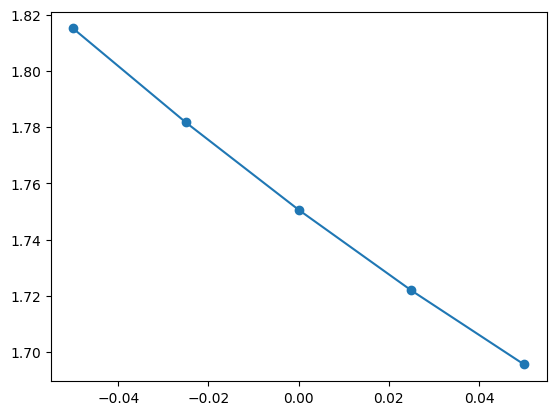

In [26]:
#Deep wave_guide TM
wavelength = np.linspace(1500, 1600,5) * nm  # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450*nm, 
    slab_thickness=0*nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2, 
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=30, 
)
print(deep_waveguide)
res_neff = deep_waveguide.n_eff #TENGO PARA CADA LONGITUD DE ONDA SU VALOR # queremos el primer modo TE# In this case, the result is not just a number, is a wavelength-dependent vector
neff_ef_lambda_fundamental_tm = res_neff.real[:,1] #el siguiente modo TM
print(neff_ef_lambda_fundamental_tm)
print(wavelength)

#ahora tenemos wavelegth y neff_ef_lambda_fundamental_te
#utilizamos polifit para sacar el polinomio de 2do orden
       # o tu variable lambda_values
y = neff_ef_lambda_fundamental_tm   
#como dice el enunciado debo hacer el desplazamiento 
lam_array = wavelength-1.55
print(lam_array)
coeffs = np.polyfit(lam_array,y , 2)  # [a, b, c]
a, b, c = coeffs
print("a, b, c =", a, b, c)
y_fit = np.polyval(coeffs, lam_array)   
plt.scatter(lam_array, y)
plt.plot(lam_array, y_fit)
plt.show()

In [27]:
n2 = b
n1 = c
n_g = n1 - n2 * 1550*nm
print("n_g(lambda0) =", n_g)

n_g(lambda0) = 3.6047604816517067


In [28]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

In [29]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

import gplugins.tidy3d.materials as mat

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

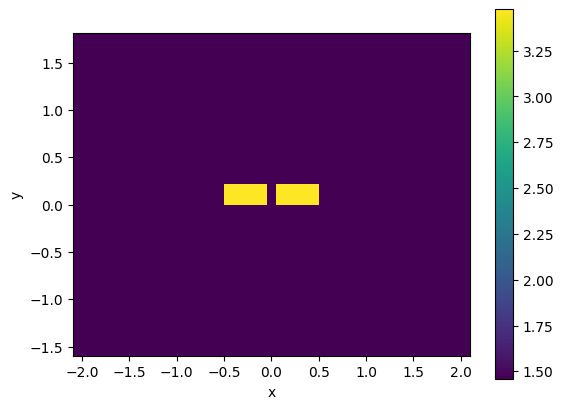

In [30]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(450*nm, 450*nm), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height 
    gap=100 * nm,
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.3, # Parameters of the grid
    grid_resolution=30 # Parameters of the grid
)

dcoupler_cs.plot_index()

In [31]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-03-23 15:37:30.402 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_01c8acf921e672df.npz.
[2.41443501+7.24898659e-05j 2.33577726+5.59185907e-05j
 1.85566515+2.21530316e-04j 1.64375834+2.58764120e-04j]


In [32]:
dcoupler_cs.fraction_te

array([0.97022893, 0.97315239, 0.04096223, 0.12588196])

In [33]:
dcoupler_cs.fraction_tm

array([0.02977107, 0.02684761, 0.95903777, 0.87411804])

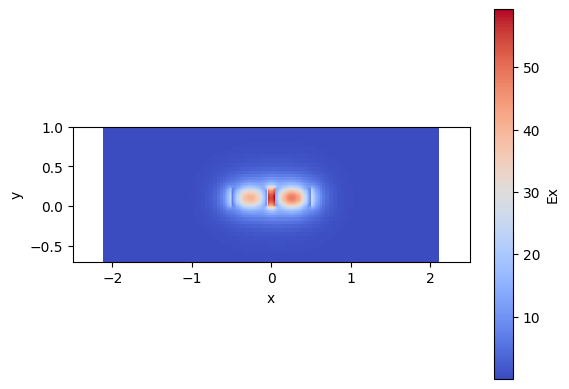

In [34]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) 

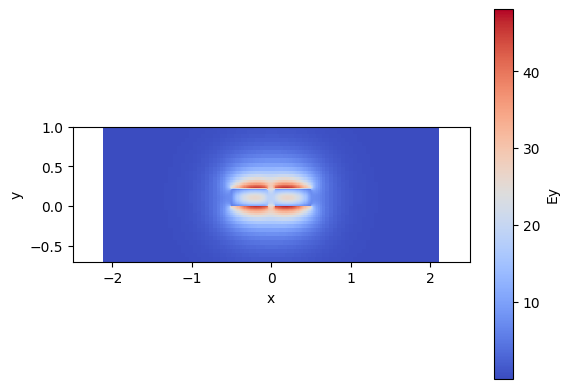

In [35]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) 

In [36]:
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

9.852811569222741
3.657267876573645


In [37]:
dcoupler_cs.coupling_length() 

array([9.85281157, 3.65726788])

In [38]:
#### fijar un gap y probar diferentes longitudes de acoplo 
#### o fijar la longitud y variar el gap para ver k

In [44]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

In [ ]:
#para el modo TE tenemos 9.852811569222741 um de Lpi
#considerando 100nm de gap

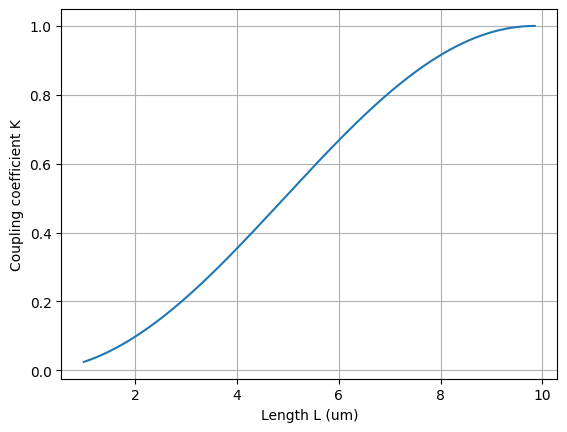

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Tu valor ya calculado
L_pi = 9.852811569222741  # um

# Sweep de longitudes
L = np.linspace(0.1*L_pi, L_pi, 2000)

# Cálculo de K
K = np.sin((np.pi/2)*(L/L_pi))**2

# Plot
plt.figure()
plt.plot(L, K)
plt.xlabel("Length L (um)")
plt.ylabel("Coupling coefficient K")
plt.grid()
plt.show()

In [84]:
targets = [0.5, 0.17, 0.23, 0.05, 0.3]

for t in targets:
    idx = np.argmin(np.abs(K - t))
    print(f"K ≈ {t} → L = {L[idx]:.4f} um (K = {K[idx]:.4f})")

K ≈ 0.5 → L = 4.9244 um (K = 0.4997)
K ≈ 0.17 → L = 2.6665 um (K = 0.1701)
K ≈ 0.23 → L = 3.1367 um (K = 0.2299)
K ≈ 0.05 → L = 1.4156 um (K = 0.0501)
K ≈ 0.3 → L = 3.6380 um (K = 0.3003)
